# EcoSort AI Classifier

## Data Collection and Dataset preparation
Firstly, we have to curate a dataset from different datasets and tailor it to our needs.
We are going to look at and download these datasets:
1. **Recyclable**: TrashNet (Gary Thung & Ming-Sheng Yang) and the TACO Dataset (`Trash Annotations in Context`). Target items: plastic bottles, aluminium beverage cans, cardboard boxes, clean glass jars.
2. **Wet (Organic)**: Source from the Waste Classification Dataset (Kaggle - `Techsash`) under category `O` (Organic) or the Food Waste Image Dataset. Target items: vegetable peels, fruit rinds, leftover food, tea bags, fallen leaves.
3. **E-waste**: Source from the Electronic Waste Classification Dataset (Kaggle) or E-Waste Image Dataset. Target items: printed circuit boards (PCBs), discarded smartphones, damaged cables/chargers, computer mice, keyboards, batteries.
4. **Dry (Non-recyclable / Residual)**: Source from the trash category of TrashNet and general residual waste subsets. Target items: soiled tissues, plastic cutlery, chip/snack multi-layer laminate wrappers, polystyrene/Styrofoam packaging.

**Note:** Our dataset is highly **_skewed_**.
1. `ewaste` has 3,002 images
2. `dry` has 702 images
3. wet` has 17,350 images
4. `recyclable` has 16,279 images
Upon considering these details, we must focus on precision/recall and F1 score, and we are not going to blindly follow the Accuracy metric.

### Import required libraries

In [2]:
# import torch and torchvision
import torch
import torchvision
print(torch.__version__, torchvision.__version__)

2.12.1+cu130 0.27.1+cu130


In [3]:
# continue with regular imports
from torch import nn
from torchvision import transforms
from torchvision.datasets import ImageFolder
from torchinfo import summary
import data_setup, engine

In [4]:
# Set up device-agnostic code
device ='cuda' if torch.cuda.is_available() else 'cpu'
device

'cuda'

### Get Data
Get the  dry, ewaste, recyclable, wet waste data to train our models.

In [5]:
from pathlib import Path
data_path = Path('data/')
data_path

WindowsPath('data')

In [6]:
# Set up train, cross val and test dir
train_dir = data_path / 'train'
val_dir = data_path / 'val'
test_dir = data_path / 'test'
train_dir, val_dir, test_dir

(WindowsPath('data/train'), WindowsPath('data/val'), WindowsPath('data/test'))

### Transform the data
Using `torchvision.transforms.v2` we shall transform the dataset and prepare dataloaders for our first model: the baseline model.

In [7]:
import torchvision.transforms.v2 as transforms
from torchvision import datasets
# Create a simple transform for our baseline model
data_transform = transforms.Compose([
    transforms.Resize((64, 64)),
    transforms.ToImage(),
    transforms.ToDtype(torch.float32, scale=True),
])
# Use the `create_dataloaders()` function from data_setup.py file
train_dataloader, val_dataloader, class_names = data_setup.create_dataloaders(train_dir,
                                                                               val_dir,
                                                                               data_transform,
                                                                               batch_size=64,
                                                                               num_workers=4)

In [8]:
train_dataloader, val_dataloader, class_names

(<torch.utils.data.dataloader.DataLoader at 0x1ffe2914ad0>,
 ['dry', 'ewaste', 'recyclable', 'wet'])

In [9]:
# Test the dataloaders
next(iter(train_dataloader))

[tensor([[[[0.5490, 0.5451, 0.5451,  ..., 0.4941, 0.4980, 0.4980],
           [0.5490, 0.5490, 0.5490,  ..., 0.5020, 0.4980, 0.5020],
           [0.5490, 0.5569, 0.5569,  ..., 0.5098, 0.5059, 0.5059],
           ...,
           [0.8588, 0.8627, 0.8588,  ..., 0.6510, 0.6314, 0.6078],
           [0.8824, 0.8784, 0.8667,  ..., 0.6588, 0.6471, 0.6275],
           [0.9020, 0.8902, 0.8706,  ..., 0.6667, 0.6588, 0.6353]],
 
          [[0.4000, 0.3961, 0.3961,  ..., 0.3647, 0.3608, 0.3608],
           [0.4000, 0.4000, 0.4000,  ..., 0.3725, 0.3608, 0.3647],
           [0.4000, 0.4078, 0.4078,  ..., 0.3804, 0.3725, 0.3686],
           ...,
           [0.7804, 0.7843, 0.7804,  ..., 0.6078, 0.5922, 0.5647],
           [0.7961, 0.7922, 0.7882,  ..., 0.6118, 0.6000, 0.5765],
           [0.8000, 0.7922, 0.7882,  ..., 0.6196, 0.6118, 0.5843]],
 
          [[0.2078, 0.2039, 0.2039,  ..., 0.1961, 0.1961, 0.1961],
           [0.2078, 0.2078, 0.2078,  ..., 0.2039, 0.1961, 0.2000],
           [0.2118, 0.21

## Making Classifiers to classify the data
We are going to make three models: a baseline, feature-extracted pretrained CNN model, and a pretrained transformer model.
### 1. Baseline Model
The baseline model is a simple CNN model that we shall train to classify the data.
For the baseline model we are going to use the ResNet-18 architecture. Source:  [ResNet-18 Architecture](https://www.geeksforgeeks.org/deep-learning/resnet18-from-scratch-using-pytorch/)

In [10]:
class BasicBlock(nn.Module):
    def __init__(self, in_channels, out_channels, stride=1):
        super().__init__()
        self.conv1 = nn.Conv2d(in_channels, out_channels, kernel_size=3, stride=stride, padding=1, bias=False)
        self.bn1 = nn.BatchNorm2d(out_channels)
        self.relu = nn.ReLU(inplace=True)
        self.conv2 = nn.Conv2d(out_channels, out_channels, kernel_size=3, stride=1, padding=1, bias=False)
        self.bn2 = nn.BatchNorm2d(out_channels)

        self.shortcut = nn.Sequential()
        if stride != 1 or in_channels != out_channels:
            self.shortcut = nn.Sequential(
                nn.Conv2d(in_channels, out_channels, kernel_size=1, stride=stride, bias=False),
                nn.BatchNorm2d(out_channels)
            )

    def forward(self, x):
        out = self.conv1(x)
        out = self.bn1(out)
        out = self.relu(out)
        out = self.conv2(out)
        out = self.bn2(out)
        out += self.shortcut(x)
        out = self.relu(out)
        return out

In [11]:
class ResNet18(nn.Module):
    def __init__(self, num_classes=len(class_names)):
        super().__init__()
        self.in_channels = 64
        self.conv1 = nn.Conv2d(3, 64, kernel_size=3, stride=1, padding=1, bias=False)
        self.bn1 = nn.BatchNorm2d(64)
        self.relu = nn.ReLU(inplace=True)

        self.layer1 = self._make_layer(BasicBlock, 64, 2, stride=1)
        self.layer2 = self._make_layer(BasicBlock, 128, 2, stride=2)
        self.layer3 = self._make_layer(BasicBlock, 256, 2, stride=2)
        self.layer4 = self._make_layer(BasicBlock, 512, 2, stride=2)

        self.avgpool = nn.AdaptiveAvgPool2d((1, 1))
        self.fc = nn.Linear(512, num_classes)

    def _make_layer(self, block, out_channels, num_blocks, stride):
        strides = [stride] + [1]*(num_blocks-1)
        layers = []
        for stride in strides:
            layers.append(block(self.in_channels, out_channels, stride))
            self.in_channels = out_channels
        return nn.Sequential(*layers)

    def forward(self, x):
        out = self.conv1(x)
        out = self.bn1(out)
        out = self.relu(out)

        out = self.layer1(out)
        out = self.layer2(out)
        out = self.layer3(out)
        out = self.layer4(out)

        out = self.avgpool(out)
        out = out.view(out.size(0), -1)
        out = self.fc(out)
        return out

model_0 = ResNet18().to(device)
print(model_0)

ResNet18(
  (conv1): Conv2d(3, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (layer1): Sequential(
    (0): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
      (shortcut): Sequential()
    )
    (1): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (conv2)

In [12]:
# 1. Get a batch of images and labels from the DataLoader
img_batch, label_batch = next(iter(train_dataloader))

# 2. Get a single image from the batch and unsqueeze the image so its shape fits the model
img_single, label_single = img_batch[0].unsqueeze(dim=0), label_batch[0]
print(f"Single image shape: {img_single.shape}\n")

# 3. Perform a forward pass on a single image
model_0.eval()
with torch.inference_mode():
    pred = model_0(img_single.to(device))

# 4. Print out what's happening and convert model logits -> pred probs -> pred label
print(f"Output logits:\n{pred}\n")
print(f"Output prediction probabilities:\n{torch.softmax(pred, dim=1)}\n")
print(f"Output prediction label:\n{torch.argmax(torch.softmax(pred, dim=1), dim=1)}\n")
print(f"Actual label:\n{label_single}")

Single image shape: torch.Size([1, 3, 64, 64])

Output logits:
tensor([[0.0294, 0.0019, 0.0083, 0.0506]], device='cuda:0')

Output prediction probabilities:
tensor([[0.2517, 0.2449, 0.2464, 0.2571]], device='cuda:0')

Output prediction label:
tensor([3], device='cuda:0')

Actual label:
2


### Training the BaseLine
Let us train the model above using training scripts.

In [13]:
from engine import train
# Set random seeds
torch.manual_seed(42)
torch.cuda.manual_seed(42)

# Set the number of epochs
NUM_EPOCHS = 5

# Setup loss function and optimizer
loss_fn = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(params=model_0.parameters(), lr=0.001)

# Start the timer
from timeit import default_timer as timer
start_time = timer()

# Train model_0
model_0_results = train(model=model_0,
                        train_dataloader=train_dataloader,
                        val_dataloader=val_dataloader,
                        optimizer=optimizer,
                        loss_fn=loss_fn,
                        epochs=NUM_EPOCHS,
                        device=device)

# End the timer and print out how long it took
end_time = timer()
print(f"[INFO] Total training time: {end_time-start_time:.3f} seconds")

  0%|          | 0/5 [00:00<?, ?it/s]

Epoch: 1 | train_loss: 0.6687 | train_acc: 0.7425 | train_f1: 0.4563 | val_loss: 0.5806 | val_acc: 0.7792 | val_f1: 0.5147
Epoch: 2 | train_loss: 0.5595 | train_acc: 0.7844 | train_f1: 0.5128 | val_loss: 0.5424 | val_acc: 0.7914 | val_f1: 0.5253
Epoch: 3 | train_loss: 0.5246 | train_acc: 0.8014 | train_f1: 0.5390 | val_loss: 0.5259 | val_acc: 0.7999 | val_f1: 0.5369
Epoch: 4 | train_loss: 0.5007 | train_acc: 0.8095 | train_f1: 0.5457 | val_loss: 0.5607 | val_acc: 0.7859 | val_f1: 0.5324
Epoch: 5 | train_loss: 0.4819 | train_acc: 0.8162 | train_f1: 0.5577 | val_loss: 0.5340 | val_acc: 0.7876 | val_f1: 0.5136
[INFO] Total training time: 361.045 seconds


In [14]:
from utils import save_model
save_model(model_0,
           target_dir='models',
           model_name='01_baseline_model.pt')

[INFO] Saving model to: models\01_baseline_model.pt


In [15]:
model_0_results

{'train_loss': [0.6687105979821454,
  0.5595117172266406,
  0.5245821804333106,
  0.5007122842533015,
  0.48192361405451006],
 'train_acc': [np.float64(0.7425415378966372),
  np.float64(0.7844313209510113),
  np.float64(0.8013830666136287),
  np.float64(0.809522352437196),
  np.float64(0.8162234937731404)],
 'train_precision': [0.49941029757149463,
  0.5490351931460105,
  0.5677219464207277,
  0.5721723786218911,
  0.6788799557960178],
 'train_recall': [0.44642347466542887,
  0.49826019563063934,
  0.5246013577363365,
  0.531993017277047,
  0.5440262116322814],
 'train_f1': [0.4562839476783715,
  0.5128421361240248,
  0.5389585468539465,
  0.5457051565183801,
  0.5576992068733613],
 'val_loss': [0.5805824932630186,
  0.542380713313431,
  0.5259162958155011,
  0.5606708320510851,
  0.5340102577049818],
 'val_acc': [np.float64(0.7792168060371202),
  np.float64(0.7913522333265348),
  np.float64(0.7999184172955334),
  np.float64(0.785947379155619),
  np.float64(0.787579033244952)],
 'val_p

**Note:** We are after the F1 score, not the blind accuracy. So, our baseline may have reached validation accuracy of ~80%, F1 score is only ~51.36%. So our goal is to make this better.

### Feature Extracting a pretrained CNN: `EfficientNetV2`
We are now going to train a transfer learning model: EfficientNetV2 (S model) based architecture. Source: [EfficientNetV2 Model Paper](https://arxiv.org/abs/2104.00298). One of the main features of EfficientNet is that it uses very low MACs as compared to other models, making it very suitable and ideal for mobile device deployment. In fact, while deciding among various models, I particularly chose EfficientNet especially the V2 for this project as it requires very few MACs for faster mobile inference. However, since EfficientNet uses Squeeze and Excitation optimization on DepthSeparable Convolution Layers (MB Blocks) to drastically reduce the number of parameters, it is not the fastest model we have to date. But for our practice, however, we must keep in mind the hardware constraints in mobile device deployment and the problem we aim to solve through this project.

In [13]:
# Creating a pretrained model
weights = torchvision.models.EfficientNet_V2_S_Weights.DEFAULT # ".DEFAULT" = best available weights
model_1 = torchvision.models.efficientnet_v2_s(weights=weights).to(device)
model_1

EfficientNet(
  (features): Sequential(
    (0): Conv2dNormActivation(
      (0): Conv2d(3, 24, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
      (1): BatchNorm2d(24, eps=0.001, momentum=0.1, affine=True, bias=True, track_running_stats=True)
      (2): SiLU(inplace=True)
    )
    (1): Sequential(
      (0): FusedMBConv(
        (block): Sequential(
          (0): Conv2dNormActivation(
            (0): Conv2d(24, 24, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
            (1): BatchNorm2d(24, eps=0.001, momentum=0.1, affine=True, bias=True, track_running_stats=True)
            (2): SiLU(inplace=True)
          )
        )
        (stochastic_depth): StochasticDepth(p=0.0, mode=row)
      )
      (1): FusedMBConv(
        (block): Sequential(
          (0): Conv2dNormActivation(
            (0): Conv2d(24, 24, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
            (1): BatchNorm2d(24, eps=0.001, momentum=0.1, affine=True, bias=T

In [14]:
# Get the transforms used to train our pretrained model
auto_transforms = weights.transforms()
auto_transforms

ImageClassification(
    crop_size=[384]
    resize_size=[384]
    mean=[0.485, 0.456, 0.406]
    std=[0.229, 0.224, 0.225]
    interpolation=InterpolationMode.BILINEAR
)

In [15]:
model_1.features    # these are the feature layers which we are going to freeze to preserve the weights

Sequential(
  (0): Conv2dNormActivation(
    (0): Conv2d(3, 24, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
    (1): BatchNorm2d(24, eps=0.001, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (2): SiLU(inplace=True)
  )
  (1): Sequential(
    (0): FusedMBConv(
      (block): Sequential(
        (0): Conv2dNormActivation(
          (0): Conv2d(24, 24, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
          (1): BatchNorm2d(24, eps=0.001, momentum=0.1, affine=True, bias=True, track_running_stats=True)
          (2): SiLU(inplace=True)
        )
      )
      (stochastic_depth): StochasticDepth(p=0.0, mode=row)
    )
    (1): FusedMBConv(
      (block): Sequential(
        (0): Conv2dNormActivation(
          (0): Conv2d(24, 24, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
          (1): BatchNorm2d(24, eps=0.001, momentum=0.1, affine=True, bias=True, track_running_stats=True)
          (2): SiLU(inplace=True)
     

In [16]:
model_1.avgpool

AdaptiveAvgPool2d(output_size=1)

In [17]:
model_1.classifier  # Final layers used to classify the images

Sequential(
  (0): Dropout(p=0.2, inplace=True)
  (1): Linear(in_features=1280, out_features=1000, bias=True)
)

In [18]:
# Create dataloaders for training the model
train_dataloader, val_dataloader, class_names = data_setup.create_dataloaders(train_dir=train_dir,
                                                                              test_dir=val_dir,
                                                                              transform=auto_transforms,
                                                                              batch_size=32,
                                                                              num_workers=0)
train_dataloader, val_dataloader, class_names

(<torch.utils.data.dataloader.DataLoader at 0x1ffe2d2e850>,
 ['dry', 'ewaste', 'recyclable', 'wet'])

#### Getting a summary with `torchinfo.summary()`
Use `torchinfo.summary()` to get a summary of the model.

In [19]:
# Print with torchinfo
from torchinfo import summary
summary(model=model_1,
        input_size=(1, 3, 224, 224),    # an example of [batch size, color_channels, height, width]
        col_names=["input_size", "output_size", "num_params", "trainable"],
        col_width=20,
        row_settings=["var_names"])

Layer (type (var_name))                                      Input Shape          Output Shape         Param #              Trainable
EfficientNet (EfficientNet)                                  [1, 3, 224, 224]     [1, 1000]            --                   True
├─Sequential (features)                                      [1, 3, 224, 224]     [1, 1280, 7, 7]      --                   True
│    └─Conv2dNormActivation (0)                              [1, 3, 224, 224]     [1, 24, 112, 112]    --                   True
│    │    └─Conv2d (0)                                       [1, 3, 224, 224]     [1, 24, 112, 112]    648                  True
│    │    └─BatchNorm2d (1)                                  [1, 24, 112, 112]    [1, 24, 112, 112]    48                   True
│    │    └─SiLU (2)                                         [1, 24, 112, 112]    [1, 24, 112, 112]    --                   --
│    └─Sequential (1)                                        [1, 24, 112, 112]    [1, 24, 112,

#### Freezing the base model and changing the output layer to suit our needs
With a feature extractor model, typically we will "freeze" the base layers of a pretrained/foundation model and then update the output layers to suit our own problem.

In [20]:
# Freeze all the base layers in EffNetV2M
for param in model_1.features.parameters():
    param.requires_grad = False # pyTorch will no longer track the gradients

In [21]:
# Update the classifier head to suit our problems
from torch import nn
model_1.classifier = nn.Sequential(
    nn.Dropout(p=0.2, inplace=True),
    nn.Linear(in_features=1280, # feature vector coming in
              out_features=len(class_names)).to(device))    # how many classes do we have?
model_1.classifier

Sequential(
  (0): Dropout(p=0.2, inplace=True)
  (1): Linear(in_features=1280, out_features=4, bias=True)
)

In [22]:
# Print with torchinfo
from torchinfo import summary
summary(model=model_1,
        input_size=(1, 3, 224, 224),    # an example of [batch size, color_channels, height, width]
        col_names=["input_size", "output_size", "num_params", "trainable"],
        col_width=20,
        row_settings=["var_names"])

Layer (type (var_name))                                      Input Shape          Output Shape         Param #              Trainable
EfficientNet (EfficientNet)                                  [1, 3, 224, 224]     [1, 4]               --                   Partial
├─Sequential (features)                                      [1, 3, 224, 224]     [1, 1280, 7, 7]      --                   False
│    └─Conv2dNormActivation (0)                              [1, 3, 224, 224]     [1, 24, 112, 112]    --                   False
│    │    └─Conv2d (0)                                       [1, 3, 224, 224]     [1, 24, 112, 112]    (648)                False
│    │    └─BatchNorm2d (1)                                  [1, 24, 112, 112]    [1, 24, 112, 112]    (48)                 False
│    │    └─SiLU (2)                                         [1, 24, 112, 112]    [1, 24, 112, 112]    --                   --
│    └─Sequential (1)                                        [1, 24, 112, 112]    [1, 2

#### Train the model
Let us now train the model, leveraging the functions I had written earlier.

In [22]:
# Define the loss function
loss_fn = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model_1.parameters(),
                             lr=0.01)

In [26]:
from timeit import default_timer as timer
start_time = timer()
# Set up training and test save the results
results = engine.train(model=model_1,
                       train_dataloader=train_dataloader,
                       val_dataloader=val_dataloader,
                       loss_fn=loss_fn,
                       optimizer=optimizer,
                       epochs=5,
                       device=torch.device(device))
# End the timer
end_time = timer()
print(f"[INFO] Total training time: {end_time-start_time:.3f} seconds")

  0%|          | 0/5 [00:00<?, ?it/s]

Epoch: 1 | train_loss: 0.4118 | train_acc: 0.8871 | train_f1: 0.7549 | val_loss: 0.2703 | val_acc: 0.9146 | val_f1: 0.7976
Epoch: 2 | train_loss: 0.4107 | train_acc: 0.8876 | train_f1: 0.7590 | val_loss: 0.2568 | val_acc: 0.9225 | val_f1: 0.8347
Epoch: 3 | train_loss: 0.4150 | train_acc: 0.8882 | train_f1: 0.7531 | val_loss: 0.2607 | val_acc: 0.9194 | val_f1: 0.8140
Epoch: 4 | train_loss: 0.4157 | train_acc: 0.8868 | train_f1: 0.7602 | val_loss: 0.2801 | val_acc: 0.9107 | val_f1: 0.8031
Epoch: 5 | train_loss: 0.4220 | train_acc: 0.8878 | train_f1: 0.7563 | val_loss: 0.2493 | val_acc: 0.9212 | val_f1: 0.8317
[INFO] Total training time: 1708.199 seconds


In [27]:
from utils import save_model
save_model(model_0,
           target_dir='models',
           model_name='02_pretrained_CNN_model.pt')

[INFO] Saving model to: models\02_pretrained_CNN_model.pt


In [28]:
results

{'train_loss': [0.4117903231685059,
  0.4106887036847013,
  0.41499477988081657,
  0.41569685492092295,
  0.42202768132588125],
 'train_acc': [np.float64(0.8870597594932835),
  np.float64(0.8876105382332242),
  np.float64(0.8881613169731648),
  np.float64(0.8868455677610845),
  np.float64(0.8878247299654234)],
 'train_precision': [0.759318859298945,
  0.7643476813328697,
  0.7559389446784951,
  0.7645186314845963,
  0.7610493972310113],
 'train_recall': [0.7511444079818308,
  0.7546699109793616,
  0.75072363954792,
  0.7565326174050561,
  0.7520984285992055],
 'train_f1': [0.7548862902278601,
  0.7590476602796239,
  0.7531241220962678,
  0.7601686409146252,
  0.756257612283435],
 'val_loss': [0.2702820695516618,
  0.25677228993401563,
  0.2607273121685979,
  0.2801030533262077,
  0.24932786417541156],
 'val_acc': [np.float64(0.9146440954517642),
  np.float64(0.9224964307566795),
  np.float64(0.9194370793391801),
  np.float64(0.9106669386090149),
  np.float64(0.9211707118090965)],
 'val

In [23]:
# Plot loss curves of a model
import matplotlib.pyplot as plt
def plot_loss_curves(results):
    """Plots training curves of a results dictionary.

    Args:
        results (dict): dictionary containing list of values, e.g.
            {"train_loss": [...],
             "train_acc": [...],
             "test_loss": [...],
             "test_acc": [...]}
    """
    train_loss = results["train_loss"]
    train_acc = results["train_acc"]
    train_precision = results["train_precision"]
    train_recall = results["train_recall"]
    train_f1 = results["train_f1"]
    val_loss = results["val_loss"]
    val_acc = results["val_acc"]
    val_precision = results["val_precision"]
    val_recall = results["val_recall"]
    val_f1 = results["val_f1"]

    epochs = range(len(results["train_loss"]))

    plt.figure(figsize=(20, 20))

    # Plot loss
    plt.subplot(5, 5, 1)
    plt.plot(epochs, train_loss, label="train_loss")
    plt.plot(epochs, val_loss, label="validation_loss")
    plt.title("Loss")
    plt.xlabel("Epochs")
    plt.legend()

    # Plot accuracy
    plt.subplot(5, 5, 2)
    plt.plot(epochs, train_acc, label="train_accuracy")
    plt.plot(epochs, val_acc, label="validation_accuracy")
    plt.title("Accuracy")
    plt.xlabel("Epochs")
    plt.legend()

    # Plot precision
    plt.subplot(5, 5, 3)
    plt.plot(epochs, train_precision, label="train_precision")
    plt.plot(epochs, val_precision, label="validation_precision")
    plt.title("Precision")
    plt.xlabel("Epochs")
    plt.legend()

    # Plot recall
    plt.subplot(5, 5, 4)
    plt.plot(epochs, train_recall, label="train_recall")
    plt.plot(epochs, val_recall, label="validation_recall")
    plt.title("Recall")
    plt.xlabel("Epochs")
    plt.legend()

    # Plot f1
    plt.subplot(5, 5, 5)
    plt.plot(epochs, train_f1, label="train_f1")
    plt.plot(epochs, val_f1, label="validation_f1")
    plt.title("F1")
    plt.xlabel("Epochs")
    plt.legend()

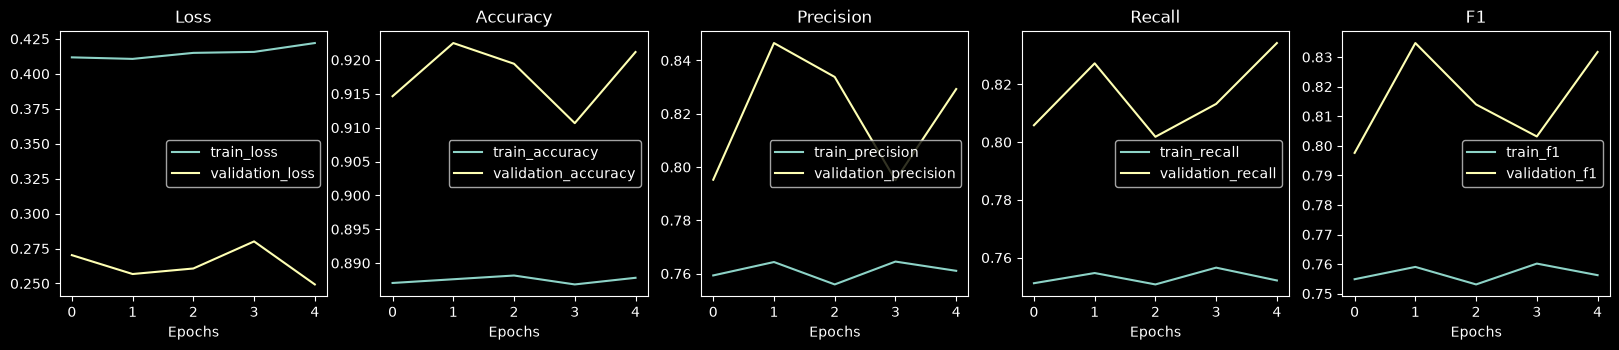

In [54]:
plot_loss_curves(results)

In [24]:
import mlxtend
print(mlxtend.__version__)

0.25.0


In [57]:
# Import tqdm.auto
from tqdm.auto import tqdm
# 1. Make predictions with the trained model
y_preds= []
model_1.eval()
with torch.inference_mode():
    for X, y in tqdm(val_dataloader, desc= "Making predictions..."):
        # Send the data and targets to the target device
        X, y = X.to(device), y.to(device)
        # Do the forward Pass
        y_logit = model_1(X)
        # Turn predictions from logits -> prediction probabilities -> prediction labels
        y_pred = torch.softmax(y_logit.squeeze(), dim=0).argmax(dim=1)
        # Put predictions on CPU for evaluation
        y_preds.append(y_pred.cpu())
    # Concatenate the list of predictions into a tensor
    # print(y_preds)
    y_pred_tensor = torch.cat(y_preds)

Making predictions...:   0%|          | 0/307 [00:00<?, ?it/s]

In [33]:
val_data = datasets.ImageFolder(val_dir,
                                auto_transforms)
val_data

Dataset ImageFolder
    Number of datapoints: 9806
    Root location: data\val
    StandardTransform
Transform: ImageClassification(
               crop_size=[384]
               resize_size=[384]
               mean=[0.485, 0.456, 0.406]
               std=[0.229, 0.224, 0.225]
               interpolation=InterpolationMode.BILINEAR
           )

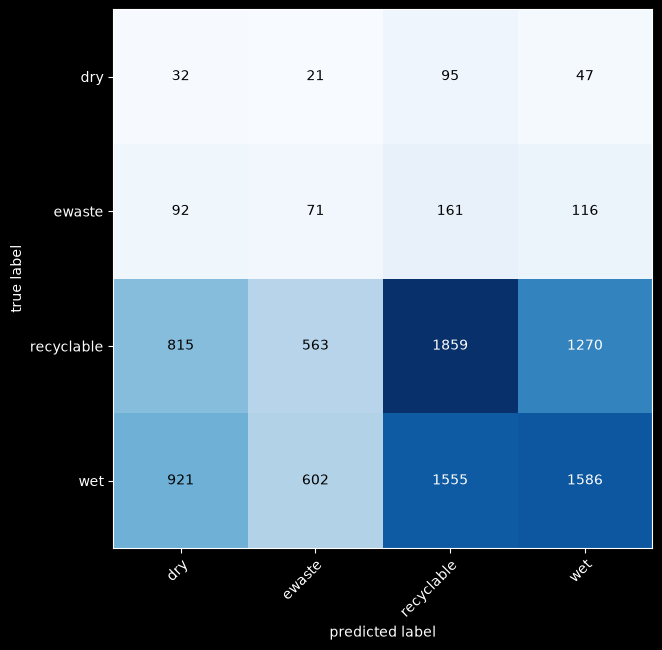

In [61]:
from torchmetrics import ConfusionMatrix
from mlxtend.plotting import plot_confusion_matrix
import torch

# 1. Convert predictions to a single tensor (if y_pred_tensor is a list of tensors)
if isinstance(y_pred_tensor, list):
    y_pred_tensor = torch.cat(y_pred_tensor)

# 2. Convert targets to tensor
targets_tensor = torch.tensor(val_data.targets)

# 3. Set up a confusion instance and compare predictions to targets
confmat = ConfusionMatrix(task='multiclass', num_classes=len(class_names))
confmat_tensor = confmat(preds=y_pred_tensor, target=targets_tensor)

# 4. Plot the confusion matrix
fig, ax = plot_confusion_matrix(
    conf_mat=confmat_tensor.numpy(),
    class_names=class_names,
    figsize=(10, 7)
)

As expected, the class imbalance is clear. The bottom half of the matrix is blue, which means the model predicts `recyclable` and `wet` more often as their samples are more in number. This is not our model's fault, rather the root issue lies in the data. This is not good. To fix this, we have to change our dataset first.

### Solving the problem
To solve this problem, we have to make a few changes to the dataloaders like:
* Distribute all the classes evenly throughout the dataloaders.
* Make sure that the classes are balanced.
To do this, we are going to use something called as a `weighted dataloader`. Details below.

In [24]:
# import libraries
import torch, torchvision
from torch import nn
from pathlib import Path
import data_setup, engine
from utils import save_model, plot_loss_curves

device = 'cuda' if torch.cuda.is_available() else 'cpu'

data_path = Path('data/')
train_dir, val_dir = data_path / 'train', data_path / 'val'

To create weighted dataloaders, we are going to call the function `create_weighted_dataloaders()` from `data_setup.py`.

In [25]:
weights = torchvision.models.EfficientNet_V2_S_Weights.DEFAULT
auto_transforms = weights.transforms()

train_dataloader, val_dataloader, class_names = data_setup.create_weighted_dataloaders(
    train_dir=train_dir,
    val_dir=val_dir,
    transform=auto_transforms,
    batch_size=32,
    num_workers=0,
    seed=42)
class_names

['dry', 'ewaste', 'recyclable', 'wet']

In [26]:
# Check whether the classes are balanced
from collections import Counter

def label_counts(loader, max_batches=100):
    c = Counter()
    for i, (_, y) in enumerate(loader):
        if i >= max_batches: break
        c.update(y.tolist())
    return {class_names[k]: v for k, v in sorted(c.items())}

print('train (first 100 batches):', label_counts(train_dataloader))
print('val   (first 100 batches):', label_counts(val_dataloader))

train (first 100 batches): {'dry': 800, 'ewaste': 788, 'recyclable': 811, 'wet': 801}
val   (first 100 batches): {'dry': 800, 'ewaste': 788, 'recyclable': 811, 'wet': 801}


In [27]:
# Create another instance of our pretrained model and feed it the weighted dataloaders.

model_2 = torchvision.models.efficientnet_v2_s(weights=weights).to(device)
for param in model_2.features.parameters():
    param.requires_grad = False
model_2.classifier = nn.Sequential(
    nn.Dropout(p=0.2, inplace=True),
    nn.Linear(in_features=1280, out_features=len(class_names))).to(device)

In [52]:
loss_fn = nn.CrossEntropyLoss()   # unweighted: the balancing is done by the loader only
optimizer = torch.optim.Adam(model_2.parameters(), lr=0.001)

from timeit import default_timer as timer
start_time = timer()
results_weighted = engine.train(model=model_2,
                                train_dataloader=train_dataloader,
                                val_dataloader=val_dataloader,
                                loss_fn=loss_fn,
                                optimizer=optimizer,
                                epochs=5,
                                device=torch.device(device))
print(f"[INFO] Total training time: {timer()-start_time:.3f} seconds")

  0%|          | 0/5 [00:00<?, ?it/s]

Epoch: 1 | train_loss: 0.3891 | train_acc: 0.8838 | train_f1: 0.8835 | val_loss: 0.2197 | val_acc: 0.9296 | val_f1: 0.9291
Epoch: 2 | train_loss: 0.3365 | train_acc: 0.8903 | train_f1: 0.8902 | val_loss: 0.2007 | val_acc: 0.9343 | val_f1: 0.9336
Epoch: 3 | train_loss: 0.3343 | train_acc: 0.8892 | train_f1: 0.8890 | val_loss: 0.1971 | val_acc: 0.9312 | val_f1: 0.9308
Epoch: 4 | train_loss: 0.3251 | train_acc: 0.8908 | train_f1: 0.8902 | val_loss: 0.2002 | val_acc: 0.9345 | val_f1: 0.9337
Epoch: 5 | train_loss: 0.3124 | train_acc: 0.8926 | train_f1: 0.8923 | val_loss: 0.1904 | val_acc: 0.9365 | val_f1: 0.9360
[INFO] Total training time: 1779.356 seconds


**Note:** Actually, I ran the above cell twice, so basically, the model was run for 10 epochs instead of 5.

In [53]:
# Save the better model
save_model(model_2, target_dir='models', model_name='03_pretrained_CNN_weighted_model.pt')

[INFO] Saving model to: models\03_pretrained_CNN_weighted_model.pt


In [54]:
results_weighted

{'train_loss': [0.38911322091110123,
  0.33648832226919334,
  0.33432511126699105,
  0.3250731263863772,
  0.31242713987200343],
 'train_acc': [np.float64(0.8837856858725254),
  np.float64(0.8902726354762707),
  np.float64(0.8891710779963894),
  np.float64(0.8907928153973257),
  np.float64(0.8925981457115756)],
 'train_precision': [0.883194834770424,
  0.8900105733223309,
  0.8888817635547543,
  0.8900814163837978,
  0.8921311784256525],
 'train_recall': [0.883905779387108,
  0.8905391104892799,
  0.8893239979974217,
  0.8903410627082824,
  0.8925475455736687],
 'train_f1': [0.883490033188172,
  0.8902239074664123,
  0.889035926869638,
  0.8901515768469653,
  0.892263046752559],
 'val_loss': [0.21966378192996747,
  0.20069346111571168,
  0.19708847866093296,
  0.20015707744303665,
  0.19043190812491828],
 'val_acc': [np.float64(0.9296349173975117),
  np.float64(0.9343259229043442),
  np.float64(0.9311645931062614),
  np.float64(0.9345298796655109),
  np.float64(0.9364674688965939)],
 '

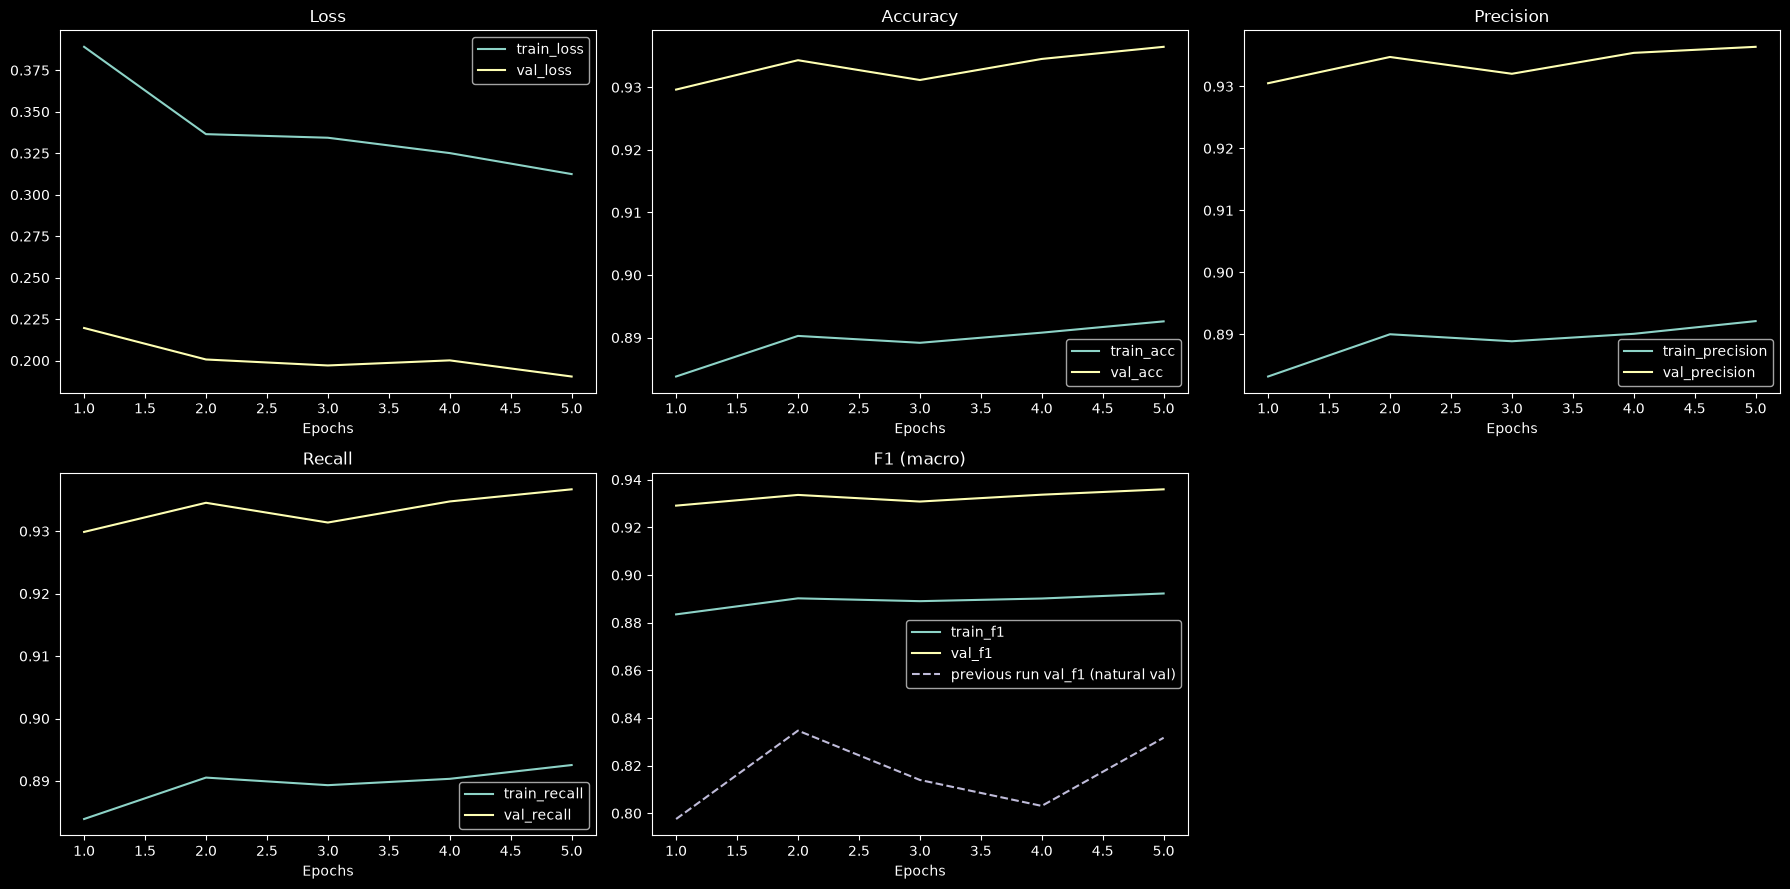

In [55]:
# Plott the loss and metric curves and compare with those of model 1
PREV_VAL_F1 = [0.7976, 0.8347, 0.8140, 0.8031, 0.8317]   # previous EfficientNetV2-S run
plot_loss_curves(results_weighted, compare={'previous run val_f1 (natural val)': PREV_VAL_F1})

              precision    recall  f1-score   support

         dry     0.3194    0.9795    0.4817       195
      ewaste     0.7861    0.9773    0.8713       440
  recyclable     0.9386    0.8509    0.8926      4507
         wet     0.9591    0.9408    0.9499      4664

    accuracy                         0.9019      9806
   macro avg     0.7508    0.9371    0.7989      9806
weighted avg     0.9292    0.9019    0.9107      9806



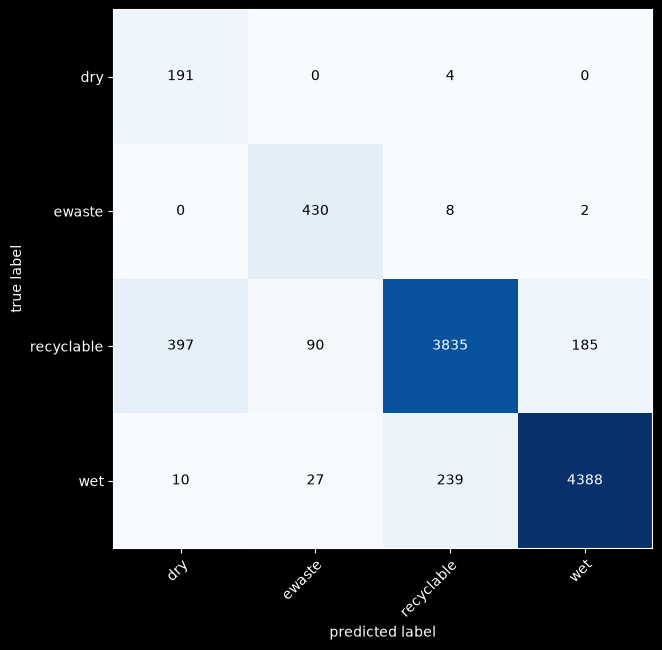

In [56]:
# plot the confusion matrix
from sklearn.metrics import classification_report
from torchmetrics import ConfusionMatrix
from mlxtend.plotting import plot_confusion_matrix

_, natural_val_dataloader, _ = data_setup.create_dataloaders(
    train_dir, val_dir, auto_transforms, batch_size=32, num_workers=0)

model_2.eval()
preds, targets = [], []
with torch.inference_mode():
    for X, y in natural_val_dataloader:
        logits = model_2(X.to(device))
        preds.append(logits.argmax(dim=1).cpu())
        targets.append(y)
preds, targets = torch.cat(preds), torch.cat(targets)

print(classification_report(targets, preds, target_names=class_names, digits=4))

confmat = ConfusionMatrix(task='multiclass', num_classes=len(class_names))
fig, ax = plot_confusion_matrix(conf_mat=confmat(preds=preds, target=targets).numpy(),
                                class_names=class_names, figsize=(10, 7))

#### Let us see how our model performs visually with some images (data).
Let us create a random batch of data and make inferences.

In [28]:
# modularize the prediction-making
def make_predictions(model: torch.nn.Module,
                     data: list,
                     device: torch.device = device):
    pred_probs = []
    model.to(device)
    model.eval()
    with torch.inference_mode():
        model.eval()
        for sample in data:
            # Prepare the sample (add a batch dimension and pass to the target device)
            sample = torch.unsqueeze(sample, dim=0).to(device)
            # Forward Pass: model outputs raw logits
            pred_logit = model(sample)
            # Get prediction probabilities (logit --> pred probs)
            pred_prob = torch.softmax(pred_logit.squeeze(), dim=0)
            #  Get pred_prob off the GPu for further calculations
            pred_probs.append(pred_prob.cpu())
    # Stack the pred_probs to turn the list into a tensor
    return torch.stack(pred_probs)

Make predictions using the above methods.

In [29]:
import random
# random.seed(42)
val_samples = []
val_labels = []
for sample, label in random.sample(list(val_data), k= 9):
   val_samples.append(sample)
   val_labels.append(label)
# View the first sample image
val_samples[0].shape
# I restarted the kernel and did not train again, so this is showing the error for that

NameError: name 'val_data' is not defined

In [67]:
# Make Predictions
pred_probs = make_predictions(model = model_2,
                              data = val_samples)
# View the first 2 prediction probabilities
pred_probs[:2]

tensor([[7.9326e-05, 2.3717e-06, 3.5151e-04, 9.9957e-01],
        [4.0713e-06, 1.5837e-03, 1.1241e-03, 9.9729e-01]])

In [68]:
# Convert prediction probabilities to labels
pred_classes = pred_probs.argmax(dim=1)
pred_classes

tensor([3, 3, 3, 3, 0, 1, 1, 3, 0])

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.0322802..2.64].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.117904..1.8158263].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.0357141..2.4285715].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.0494049..2.64].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.177871..2.6051416].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.8506721..2.64].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.0151556..2.64].
Clippin

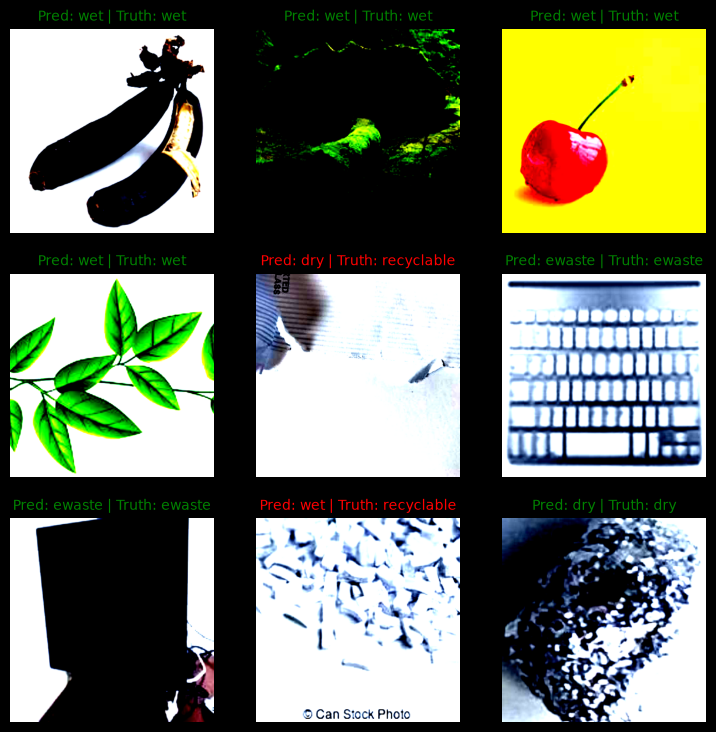

In [69]:
# Plot the predictions
import matplotlib.pyplot as plt
plt.figure(figsize=(9, 9))
nrows= 3
ncols= 3
for i, sample in enumerate(val_samples):
    # Create subplot
    plt.subplot(nrows, ncols, i+1)
    # Plot the target image
    sample = sample.permute(1, 2, 0)
    plt.imshow(sample.squeeze(), cmap='gray')
    # Find the prediction (in test form, e.g. "Sandal")
    pred_label = class_names[pred_classes[i]]
    # Get the truth labels (in text form)
    truth_label = class_names[val_labels[i]]
    # Create a title for the plot
    title_text = f"Pred: {pred_label} | Truth: {truth_label}"
    # Check the equality between pred and truth and change the colour of title text
    if pred_label == truth_label:
        plt.title(title_text, fontsize=10, c='g')
    else:
        plt.title(title_text, fontsize=10, c='r')
    plt.axis(False);

OK, so our model is somewhat 'good'. It is actually pretty good, ngl. But since waste management is a serious task and needs to be carefully, we have to make sure that the precision/recall/F1 score metrics are maximized. So we will train one final model: an attention-based pretrained model, that is, a **Vision Transformer (ViT)** model.

### The Vision Transformer (ViT) - the SOTA ??
A Vision Transformer (ViT) is a transformer-based model that has been proposed in the paper [An Image is Worth 16x16 Words: Transformers for Image Recognition at Scale](https://welzin.ai/papers/vit.pdf)

In [29]:
# import libraries
import torch, torchvision
from torch import nn
from pathlib import Path
import data_setup, engine
from utils import save_model, plot_loss_curves

device = 'cuda' if torch.cuda.is_available() else 'cpu'

data_path = Path('data/')
train_dir, val_dir = data_path / 'train', data_path / 'val'

In [30]:
weights = torchvision.models.ViT_L_16_Weights.DEFAULT

auto_transforms = weights.transforms()

train_dataloader, val_dataloader, class_names = data_setup.create_weighted_dataloaders(
    train_dir=train_dir,
    val_dir=val_dir,
    transform=auto_transforms,
    batch_size=32,
    num_workers=0
)
class_names

['dry', 'ewaste', 'recyclable', 'wet']

In [31]:
# Check whether the classes are balanced
from collections import Counter

def label_counts(loader, max_batches=100):
    c = Counter()
    for i, (_, y) in enumerate(loader):
        if i >= max_batches: break
        c.update(y.tolist())
    return {class_names[k]: v for k, v in sorted(c.items())}

print('train (first 100 batches):', label_counts(train_dataloader))
print('val   (first 100 batches):', label_counts(val_dataloader))

train (first 100 batches): {'dry': 800, 'ewaste': 788, 'recyclable': 811, 'wet': 801}
val   (first 100 batches): {'dry': 800, 'ewaste': 788, 'recyclable': 811, 'wet': 801}


In [33]:
# Create another instance of our pretrained model and feed it the weighted dataloaders.
model_3 = torchvision.models.vit_l_16(weights=weights).to(device)

In [34]:
# Print with torchinfo
from torchinfo import summary
summary(model=model_3,
        input_size=(1, 3, 224, 224),    # an example of [batch size, color_channels, height, width]
        col_names=["input_size", "output_size", "num_params", "trainable"],
        col_width=20,
        row_settings=["var_names"])

Layer (type (var_name))                                      Input Shape          Output Shape         Param #              Trainable
VisionTransformer (VisionTransformer)                        [1, 3, 224, 224]     [1, 1000]            1,024                True
├─Conv2d (conv_proj)                                         [1, 3, 224, 224]     [1, 1024, 14, 14]    787,456              True
├─Encoder (encoder)                                          [1, 197, 1024]       [1, 197, 1024]       201,728              True
│    └─Dropout (dropout)                                     [1, 197, 1024]       [1, 197, 1024]       --                   --
│    └─Sequential (layers)                                   [1, 197, 1024]       [1, 197, 1024]       --                   True
│    │    └─EncoderBlock (encoder_layer_0)                   [1, 197, 1024]       [1, 197, 1024]       12,596,224           True
│    │    └─EncoderBlock (encoder_layer_1)                   [1, 197, 1024]       [1, 197, 102

In [35]:
for param in model_3.parameters():
    param.requires_grad = False
for param in model_3.encoder.ln.parameters():
    param.requires_grad = True

In [36]:
# Update the classifier head to suit our problems
model_3.heads = nn.Sequential(
    nn.Dropout(p=0.2, inplace=True),
    nn.Linear(in_features=1024, # feature vector coming in
              out_features=len(class_names)).to(device))    # how many classes do we have?
model_3.heads

Sequential(
  (0): Dropout(p=0.2, inplace=True)
  (1): Linear(in_features=1024, out_features=4, bias=True)
)

In [37]:
summary(model=model_3,
        input_size=(1, 3, 224, 224),    # an example of [batch size, color_channels, height, width]
        col_names=["input_size", "output_size", "num_params", "trainable"],
        col_width=20,
        row_settings=["var_names"])

Layer (type (var_name))                                      Input Shape          Output Shape         Param #              Trainable
VisionTransformer (VisionTransformer)                        [1, 3, 224, 224]     [1, 4]               1,024                Partial
├─Conv2d (conv_proj)                                         [1, 3, 224, 224]     [1, 1024, 14, 14]    (787,456)            False
├─Encoder (encoder)                                          [1, 197, 1024]       [1, 197, 1024]       201,728              Partial
│    └─Dropout (dropout)                                     [1, 197, 1024]       [1, 197, 1024]       --                   --
│    └─Sequential (layers)                                   [1, 197, 1024]       [1, 197, 1024]       --                   False
│    │    └─EncoderBlock (encoder_layer_0)                   [1, 197, 1024]       [1, 197, 1024]       (12,596,224)         False
│    │    └─EncoderBlock (encoder_layer_1)                   [1, 197, 1024]       [1,

In [ ]:
loss_fn = nn.CrossEntropyLoss()   # unweighted: the balancing is done by the loader only
optimizer = torch.optim.Adam(model_3.parameters(), lr=0.001)

from timeit import default_timer as timer
start_time = timer()
results_weighted = engine.train(model=model_3,
                                train_dataloader=train_dataloader,
                                val_dataloader=val_dataloader,
                                loss_fn=loss_fn,
                                optimizer=optimizer,
                                epochs=5,
                                device=torch.device(device))
print(f"[INFO] Total training time: {timer()-start_time:.3f} seconds")

  0%|          | 0/5 [00:00<?, ?it/s]

Epoch: 1 | train_loss: 0.2599 | train_acc: 0.9182 | train_f1: 0.9180 | val_loss: 0.1676 | val_acc: 0.9466 | val_f1: 0.9464


In [ ]:
# Save the better model
save_model(model_3, target_dir='models', model_name='04_pretrained_transformer_model.pt')

In [28]:
# copy results obtained from kaggle
results_tr = {"train_loss": [0.7542300034759096, 0.3750316848843532, 0.293434087602593, 0.2565711439530677, 0.23199906891281125, 0.21157671678847761, 0.20475345752302215, 0.19305802741745914, 0.1850039865639345, 0.17663808199057607, 0.17813751062126776, 0.17680192222625543, 0.17095595602594943, 0.16404249583992472, 0.1609051931000619], "train_acc": [0.7714574217435207, 0.9007068327162572, 0.9158838468835103, 0.9248187019981029, 0.9306018787674796, 0.9359260732535725, 0.9385269728588477, 0.9405770937241823, 0.9443407484471099, 0.9448303295492794, 0.9460848811235887, 0.945534102383648, 0.9477678161622961, 0.9490835653743765, 0.9510418897830544], "train_precision": [0.7727377029683375, 0.9003265077518493, 0.9164468707553921, 0.9248834701303787, 0.9305370130604455, 0.9357390295334609, 0.9385375513452465, 0.9405689865055974, 0.9443056404154166, 0.9447019565520283, 0.9460528676917719, 0.9454661487135085, 0.9479504207760169, 0.9491486239619908, 0.9513268935241005], "train_recall": [0.771874534764738, 0.9004855726017362, 0.916229703830939, 0.9249552420728464, 0.9302454121773114, 0.9361623436480788, 0.938794334034134, 0.940722596205947, 0.9439294645916672, 0.9448481436863547, 0.945894486545741, 0.9456782077058521, 0.9477675904432019, 0.9492545796599423, 0.9511605053787301], "train_f1": [0.7710313732161865, 0.9002183550428328, 0.9160692698682381, 0.9246378590644496, 0.9300145133708374, 0.9355981076651921, 0.9383336216483634, 0.9402972208500009, 0.9438034474695145, 0.9444146898760313, 0.9456327980163408, 0.945201601967762, 0.9475648197957129, 0.9488827724320159, 0.9509177504485279], "val_loss": [0.45239940924303873, 0.3171766400337219, 0.2648373681616473, 0.23469009206860098, 0.2169476006808993, 0.20480288332932955, 0.19408777123921878, 0.18720622041395732, 0.17986009047402965, 0.1750292813816628, 0.17132355981542693, 0.16711751657066407, 0.16341492567550053, 0.1617670419154229, 0.15918867856070593], "val_acc": [0.8965939220885172, 0.9138282684070977, 0.91974301448093, 0.9272894146440954, 0.9333061390985111, 0.9378951662247603, 0.9385070365082603, 0.94003671221701, 0.9453395880073424, 0.9446257393432592, 0.9482969610442586, 0.9487048745665919, 0.9475831123801755, 0.9502345502753416, 0.9506424637976749], "val_precision": [0.8971401430919113, 0.9148159201231053, 0.9203333398312382, 0.9274521727177297, 0.933372207266475, 0.9380996941398079, 0.9389130840586564, 0.9403221697820843, 0.9455570807058175, 0.9448819095397929, 0.9484868868847037, 0.9488088172167025, 0.9477071615800277, 0.9504274381889515, 0.9507142005509022], "val_recall": [0.8968940035229922, 0.9140440226384504, 0.9199430398251858, 0.9275126389064016, 0.9335150061808213, 0.9381195931301975, 0.9387175349192123, 0.9402355681843293, 0.9455610182147828, 0.9448084252889999, 0.9485104938553797, 0.948890512775117, 0.9477664517624028, 0.950421644794054, 0.9508274266396315], "val_f1": [0.8966554824813623, 0.9140079731268227, 0.9199362229110679, 0.9273086538562834, 0.9332815738140934, 0.9378584702266672, 0.9385821983785615, 0.9400868701101308, 0.9451142180999801, 0.9446727328080927, 0.9481290361454369, 0.9486411578695454, 0.9474846699068113, 0.9501634991528012, 0.950480027222478]}

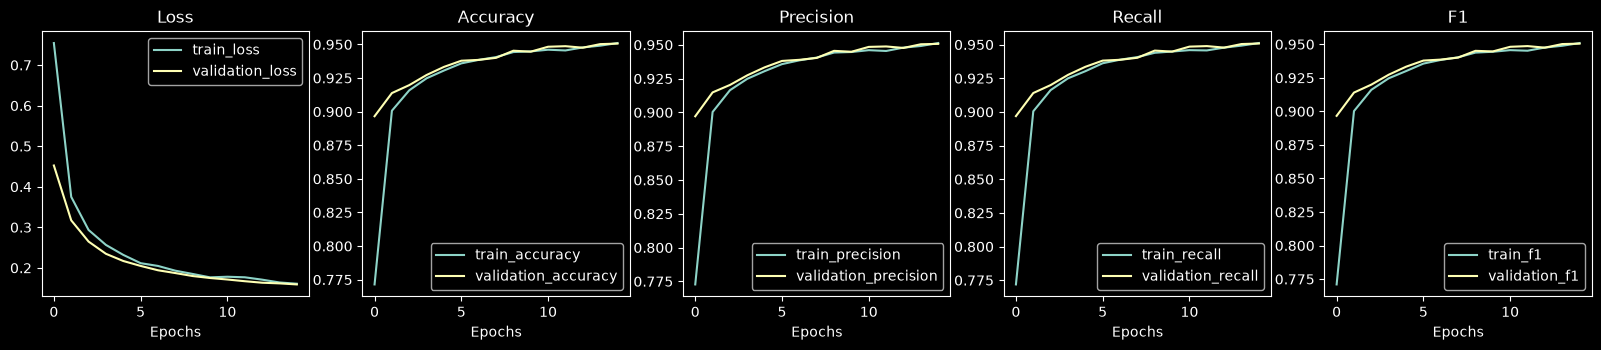

In [27]:
# Plott the loss and metric curves and compare with those of model 1
PREV_VAL_F1 = [0.7976, 0.8347, 0.8140, 0.8031, 0.8317]   # previous EfficientNetV2-S run
plot_loss_curves(results_tr)

Indeed, it is the SOTA model. One may question that we trained it for 15 epochs and not 5 or 10. Well, look at the F1 score we got at the 10th epoch.

In [32]:
# plot the confusion matrix
from sklearn.metrics import classification_report
from torchmetrics import ConfusionMatrix
from mlxtend.plotting import plot_confusion_matrix

_, natural_val_dataloader, _ = data_setup.create_dataloaders(
    train_dir, val_dir, auto_transforms, batch_size=32, num_workers=0)

In [39]:
model_3.load_state_dict(torch.load('models/04_pretrained_transformer.pt', map_location=device))

<All keys matched successfully>

              precision    recall  f1-score   support

         dry     0.3802    0.9846    0.5486       195
      ewaste     0.8765    0.9841    0.9272       440
  recyclable     0.9573    0.8811    0.9176      4507
         wet     0.9599    0.9588    0.9593      4664

    accuracy                         0.9247      9806
   macro avg     0.7935    0.9522    0.8382      9806
weighted avg     0.9434    0.9247    0.9306      9806



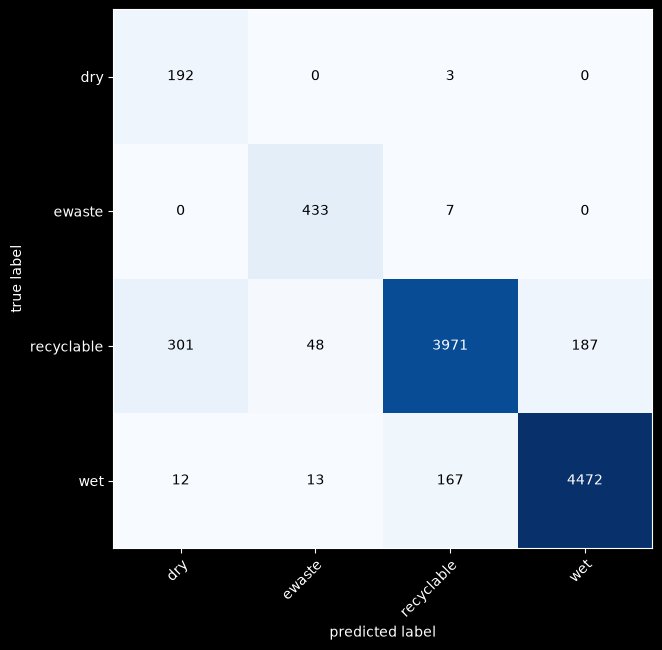

In [41]:
model_3.eval()
preds, targets = [], []
with torch.inference_mode():
    for X, y in natural_val_dataloader:
        logits = model_3(X.to(device))
        preds.append(logits.argmax(dim=1).cpu())
        targets.append(y)
preds, targets = torch.cat(preds), torch.cat(targets)

print(classification_report(targets, preds, target_names=class_names, digits=4))

confmat = ConfusionMatrix(task='multiclass', num_classes=len(class_names))
fig, ax = plot_confusion_matrix(conf_mat=confmat(preds=preds, target=targets).numpy(),
                                class_names=class_names, figsize=(10, 7))

In [42]:
# Export as onnx
onnx_model_path = Path('models') / 'ecosort-ai-sota.onnx'
torch.onnx.export(model_3,
                  (torch.randn(1, 3, 224, 224).to(device),),
                  onnx_model_path,
                  export_params=True,
                  opset_version=18,
                  do_constant_folding=True,
                  input_names=['input'],
                  output_names=['output'],
                  dynamic_axes={'input': {0: 'batch_size'},
                                'output': {0: 'batch_size'}})
print(f"Exported ONNX model to {onnx_model_path}")

C:\Users\Subhodeep\AppData\Local\Temp\ipykernel_31596\3912096344.py:3: UserWarning: # 'dynamic_axes' is not recommended when dynamo=True, and may lead to 'torch._dynamo.exc.UserError: Constraints violated.' Supply the 'dynamic_shapes' argument instead if export is unsuccessful.
  torch.onnx.export(model_3,
W1004 01:21:59.589000 31596 Lib\site-packages\torch\utils\flop_counter.py:29] triton not found; flop counting will not work for triton kernels


[torch.onnx] Obtain model graph for `VisionTransformer([...]` with `torch.export.export(..., strict=False)`...
[torch.onnx] Obtain model graph for `VisionTransformer([...]` with `torch.export.export(..., strict=False)`... ✅
[torch.onnx] Run decompositions...


C:\Users\Subhodeep\AppData\Local\Programs\Python\Python314\Lib\copyreg.py:104: FutureWarning: `isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.
  return cls.__new__(cls, *args)


[torch.onnx] Run decompositions... ✅
[torch.onnx] Translate the graph into ONNX...
[torch.onnx] Translate the graph into ONNX... ✅
[torch.onnx] Optimize the ONNX graph...
[torch.onnx] Optimize the ONNX graph... ✅
Exported ONNX model to models\ecosort-ai-sota.onnx
